In [1]:
#phase 1 step 1, imports and setup
#sources, every notebook day uses this same import block
#slides, week 2 overview introduces all metrics imported here


#we load all the libraries we need for the project,
#numpy and pandas helps us work with numbers and tables,
#matplotlib helps us draw charts and plots,
#sklearn gives us the three models we will train later on,
#splits our data into train and test sets,
#and last but not least randomstate=42 is a seed number,
#meaning every time we run this notebook we get the same results
#ensuring our results will be consistent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

#done

In [2]:
#phase 1 step 2
#load the dataset and explore it
#sources, evaluation exercise beyond accuracy notebook day 10
#slides, week 2 day 6, accuracy pitfalls and class imbalance,
#week 2 day 7, when to use f1 over accuracy


#here we read the titanic dataset csv file so we can get a first look,
#printing shape to check the amount of rows and columns,
#we check the dtypes(data types) to the the types of data in each column
#then we check th missing values so we know what need fixing in the next step
#after all of that, we check the class balance to see how many passengers survived vs no
#if one class is much larger than the other, accuracy alone isnt relaible and we should use f1
#
df = pd.read_csv("Titanic-Dataset.csv")

print(df.shape)
print()
print(df.head())
print()
print(df.dtypes)
print()
print("missing values per column")
print(df.isnull().sum())
print()
print("class balance (survived)")
print(df["Survived"].value_counts())
print()
print("positive rate", round(df["Survived"].mean(), 3))




(891, 12)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN   

In [3]:
#phase 1 step 3
#prepare the data
#sources, classification basics notebook day 13
#slides, week 2 day 9, data leakage explanation,
#week 3 day 11, overfitting and why clean splits matter


#in this part we clean the data so the model can actually learn from it
#dropping columns that are either useless for prediction(passengerid or name or ticket)
#or having too many missing values to be relaible, we saw that cabin is missing 77%
#of rows so we remove it completly, then we fill the 177 missing age values with the median age
#which is more reliable than the mean when there are extreme values in our data
#then filling the 2 missing embarked values with the most common port
#after that we convert the text columns sex and embarked into numbers because
#sklearn models can only work with numbers not words, lastly we separate the features x from label y
#and split everything, 80% for training and 20% for testing with stratify so both sets
#have the same survival rate as the full dataset


df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})
X = df.drop(columns=["Survived"])
y = df["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("train survived rate:", round(y_train.mean(), 3))
print("test survived rate:", round(y_test.mean(), 3))

X_train shape: (712, 7)
X_test shape: (179, 7)
train survived rate: 0.383
test survived rate: 0.385


logistic regression
  accuracy : 0.804
  precision: 0.793
  recall   : 0.667
  f1-score : 0.724



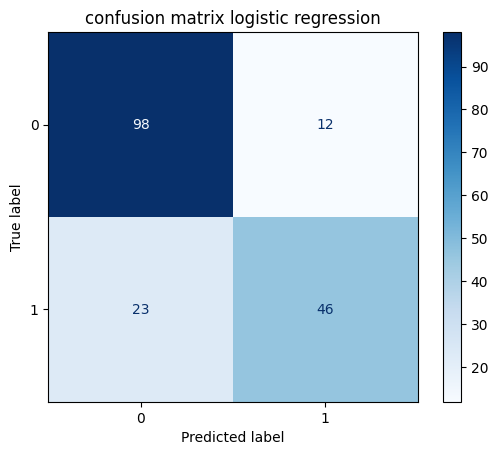

decision tree
  accuracy : 0.821
  precision: 0.794
  recall   : 0.725
  f1-score : 0.758



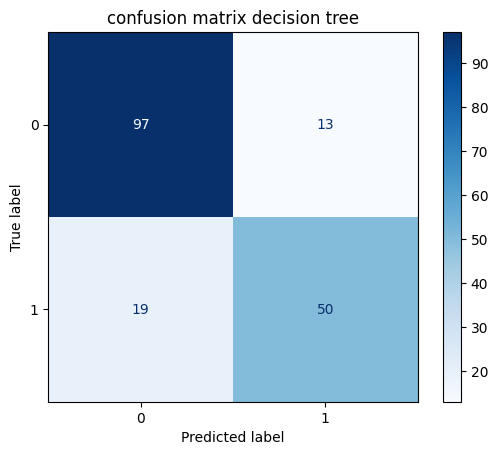

random forest
  accuracy : 0.816
  precision: 0.781
  recall   : 0.725
  f1-score : 0.752



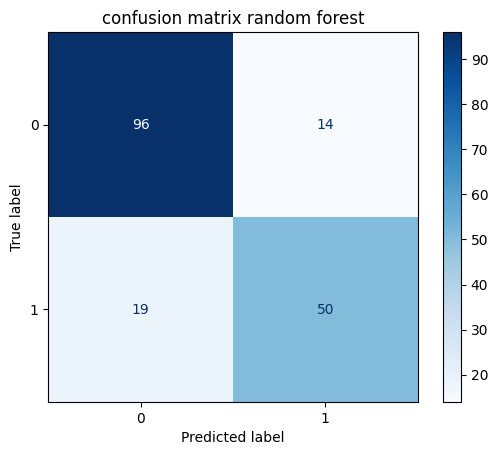

In [4]:
#phase 1 step 4
#train 3 models and compare results
#sources, decision trees splits and rules notebook day 11,
#random forest ensemble of trees notebook day 12,
#evaluation exercise beyond accuracy notebook day 11
#slides, week 3 day 11, decision trees,
#week 3 day 12, random forest,
#week 2 day 8, confusion matrix


#me
#here we define a function called evaluate model that trains one model and
#runs it on the test set and prints four scores, accuracy, precision, recall,
#and f1. also drawing a confusion matrix which shows us not only how many mistakes the model made
#but what kind, did it miss survivors or incorrectly predict someone survived when they didnt
#we call this function 3 times, one for each model, logistic regression draws a straight line to separate
# the two classes, decision tree asks a series of yes or no questions to reach a prediction
#which usually gives a more reliable result than a single tree, saving each result so in the next step we can compare them all in one table


results = []

model_lr = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, zero_division=0)

print("logistic regression")
print("  accuracy :", round(float(acc_lr),  3))
print("  precision:", round(float(prec_lr), 3))
print("  recall   :", round(float(rec_lr),  3))
print("  f1-score :", round(float(f1_lr),   3))
print()

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("confusion matrix logistic regression")
plt.show()

results.append({"model": "logistic regression", "accuracy": round(float(acc_lr), 3),
                "precision": round(float(prec_lr), 3), "recall": round(float(rec_lr), 3),
                "f1": round(float(f1_lr), 3)})

model_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)

acc_dt  = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt, zero_division=0)
rec_dt  = recall_score(y_test, y_pred_dt, zero_division=0)
f1_dt   = f1_score(y_test, y_pred_dt, zero_division=0)

print("decision tree")
print("  accuracy :", round(float(acc_dt),  3))
print("  precision:", round(float(prec_dt), 3))
print("  recall   :", round(float(rec_dt),  3))
print("  f1-score :", round(float(f1_dt),   3))
print()

cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("confusion matrix decision tree")
plt.show()

results.append({"model": "decision tree", "accuracy": round(float(acc_dt), 3),
                "precision": round(float(prec_dt), 3), "recall": round(float(rec_dt), 3),
                "f1": round(float(f1_dt), 3)})


model_rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)

print("random forest")
print("  accuracy :", round(float(acc_rf),  3))
print("  precision:", round(float(prec_rf), 3))
print("  recall   :", round(float(rec_rf),  3))
print("  f1-score :", round(float(f1_rf),   3))
print()

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("confusion matrix random forest")
plt.show()

results.append({"model": "random forest", "accuracy": round(float(acc_rf), 3),
                "precision": round(float(prec_rf), 3), "recall": round(float(rec_rf), 3),
                "f1": round(float(f1_rf), 3)})

In [5]:
#phase 1 step 5
#summary table and best model choice
#sources, evaluation exercise beyond accuracy notebook day 10
#slides, week 2 day 7, f1 as main metric for imbalanced data,
#week 2 day 10, choosing and justifying metrics


#me
#here we put all three results into one table making it easier to compare side by side
#then we pick the best model based off f1 instead of accuracy because its more reliable here
# due to the fact the it balances precision and recall and we are told to use it as the main metric when classes arent perfectly
#equal in size.



summary = pd.DataFrame(results)
print("model comparison summary:")
print(summary.to_string(index=False))
print()
best = summary.loc[summary["f1"].idxmax(), "model"]
print("best model:", best)
print("reason: highest f1-score, which balances precision and recall.")
print("f1 is preferred here because the classes are mildly imbalanced.")

model comparison summary:
              model  accuracy  precision  recall    f1
logistic regression     0.804      0.793   0.667 0.724
      decision tree     0.821      0.794   0.725 0.758
      random forest     0.816      0.781   0.725 0.752

best model: decision tree
reason: highest f1-score, which balances precision and recall.
f1 is preferred here because the classes are mildly imbalanced.


In [ ]:
#phase 2 step 1
#build and train a neural network
#sources,what is a neural network notebook day 21,
#dense layers fully connected networks notebook day 22,
#build first neural network notebook day 23
#slides,week 5 day 23, activation functions and dense layers,
#week 5 day 24, dropout and overfitting


#this cell builds a neural network using keras which is the same tool
#used in the build first neural network notebook
#we use the same x_train and x_test from step 1 with no new data prep needed
#the network has two dense layers with relu activation which means each
#neuron only passes on positive values and ignores negative ones
#the final layer has one neuron with sigmoid activation which squashes
#the output to a number between 0 and 1 so we can treat it as a
#probability of survival
#we train for 20 epochs and keep 20% of the training data as a validation
#set so we can watch for overfitting

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

model_nn = Sequential([
    Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(1, activation="sigmoid"),
])

model_nn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model_nn.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0,
)

print("training complete")
print("final train accuracy:", round(float(history.history["accuracy"][-1]), 3))
print("final val accuracy  :", round(float(history.history["val_accuracy"][-1]), 3))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# phase 2 step 2
#plot training vs validation loss and accuracy curves
#sources, build first neural network notebook day 23 activity
#week 5 day 23 training history and overfitting detection,
#week 4 day 19 learning curves and the train/val gap

#me
#here we draw two charts sided by side, one for loss and the other for accuracy
#across all 50 "epochs of training". the training line shows how the model improved
#on the data it learned from. the validation line shows the preformance on data its never seen before
#if training is improving but validation levels are off or get worse, it means the model
# is overfitting, memorizing instead of learning


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("loss curve")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.title("accuracy curve")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#phase 2 step 3
#evaluate the neural network and compare with step 1
#sources, evaluation exercise beyond accuracy notebook day 11,
#classification basics notebook day 13
#slides, week 2 day 6, accuracy and precision,
#week 2 day 7, recall and f1,
#week 2 day 8, confusion matrix

#me
#last but not least we run the trained nueral network on the test set
#using the same 4 metrics we used in the second step(accuracy, precision, recall, and f1)
#it outputs a probabiltiy between 0 and 1 for each passenger, so we apply a threshold of .5, anything above .5
#is predicted as survived. after that we add the result of the nueral network to the summary table from step 2
#so the models sit side by side, plain english

proba = model_nn.predict(X_test, verbose=0)
y_pred_nn = (proba >= 0.5).astype(int).flatten()

acc_nn  = accuracy_score(y_test, y_pred_nn)
prec_nn = precision_score(y_test, y_pred_nn, zero_division=0)
rec_nn  = recall_score(y_test, y_pred_nn, zero_division=0)
f1_nn   = f1_score(y_test, y_pred_nn, zero_division=0)

print("neural network")
print("  accuracy :", round(float(acc_nn),  3))
print("  precision:", round(float(prec_nn), 3))
print("  recall   :", round(float(rec_nn),  3))
print("  f1-score :", round(float(f1_nn),   3))
print()

cm_nn = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("confusion matrix neural network")
plt.show()

nn_result = {"model": "neural network", "accuracy": round(float(acc_nn), 3),
             "precision": round(float(prec_nn), 3), "recall": round(float(rec_nn), 3),
             "f1": round(float(f1_nn), 3)}

full_summary = pd.DataFrame(results + [nn_result])
print("full model comparison summary:")
print(full_summary.to_string(index=False))
print()

best_overall = full_summary.loc[full_summary["f1"].idxmax(), "model"]
print("best overall model:", best_overall)